# Trabajo práctico integrador - Grupo 4
El comitente posee un sistema desarrollado sobre una web, con un carrusel que muestra a los usuarios juegos que pueden interesarle al cliente, siendo actualmente de manera aleatoria.<br>
El catalogo esta fomado por 100 juegos, esto no va a cambiar, ya que se baso en metacritics para su seleccion y le ha surtido efecto.<br>
No obstante, recibe muchos usuarios nuevos todo el tiempo y que, con un promedio de compra alrededor de 7 u 8 artículos cada uno, a lo sumo algunos comprarán 10, pero puede cambiar en cualquier momento, si la situación mejora.

## Fase 1 - Entendimiento del negocio

Nuestro objetivo en esta fase es entender el problema de negocio y traducirlo a un problema de minería de datos.

### Actividad 1.1: antecedentes

### Actividad 1.2: Evaluar la situacion actual

El caso a tratar es sobre una plataforma virtual de venta de videojuegos. Contamos con la siguiente información del sistema:<br>
<br>
* Hay un total de 100 juegos en venta.
* El sistema actual de recomendación muestra artículos aleatorios.
* No se cuenta con una base de datos (no hay usuarios, ni preferencias, ni ítems).

<br>
Y como supuestos del problema:

* No se agregarán nuevos ítems al carrusel.
* Cada usuario suele comprar entre 7 y 8 con una varianza de 10 juegos.

### Actividad: 1.3 Determinar los objetivos de la minería de datos

El objetivo de la minería de datos es crear un sistema recomendador capaz de recomendar k videojuegos a un usuario determinado, de tal forma que las recomendaciones cumplan con los siguientes requisitos:<br>
<br>
* Novedad: El sistema recomendador no debe recomendar videojuegos ya puntuados por el usuario.
* Diversidad: La diversidad de las recomendaciones generadas por el sistema recomendador no deberá ser inferior en más de un 20% a la diversidad obtenida mediante un sistema de recomendaciones aleatorias.
* Serendipia: Al menos un 15% de los artículos recomendados deben ser inesperados para el usuario.
* Relevancia: Al menos un 60% de los artículos recomendados deberán ser relevantes para el usuario.
<br>

**NOTA PARA EL FUTURO, BORRAR DESPUÉS**

PARA VERIFICAR LA SERENDIPIA: Se considerarán recomendaciones esperables aquellas que coincidan con las sugerencias obtenidas mediante un modelo trivial de recomendación (por ejemplo, basado en popularidad o similitud directa con artículos consumidos previamente por ese usuario). Las recomendaciones que resulten relevantes para el usuario pero no pertenezcan a ese conjunto serán consideradas serendípicas.

PARA VERIFICAR LA RELEVANCIA: Un ítem es relevante si cumple en cierta medida con las preferencias del usuario (habría que ajustar como medimos si cumple o no)

PARA VERIFICAR LA NOVEDAD: Fijarse nomás si el ítem recomendado ya tiene rating por parte del usuario (si ya lo tiene, está mal, no cumple)

PARA VERIFICAR LA DIVERSIDAD: Mepa que hay métricas de diversidad hechas para esto, utilizaremos esta, más adelante vemos.

### Actividad: 1.4: Elaborar un plan de proyecto

Hasta ahora planteamos los objetivos de negocio (lo que quieren los stakeholders), analizamos la situación actual y determinamos qué queremos lograr en el proceso de minería de datos. A partir de ahora, el plan es el siguiente: <br>
<br>
1. **Entender los datos:** Coincide con la fase 2 de CRISP-DM. Buscamos:
    * Familiarizarnos con el dataset.
    * Analizar cada atributo (tipo, semántica, rango).
    * Detectar anomalías
    * Verificar la calidad de los datos.
2. **Preparar los datos para el modelo:** Coincide con la fase 3 de CRISP-DM. Buscamos:
    * Asegurar la calidad de los datos.
    * Preparar esos datos para el modelado.
3. **Modelar el sistema recomendador:** Coincide con la fase 4 de CRISP-DM. Buscamos:
    * Seleccionar la técnica de modelado adecuada basándonos en la información obtenida en todo el proceso anterior.
    * Definir métricas de evaluación de los sistemas recomendadores candidatos.
    * Construir los sistemas recomendadores.
    * Evaluarlos según los criterios definidos anteriormente.
    * Elegir el sistema recomendador que más se ajuste a esos criterios.
4. **Evaluar el modelo:** Coincide con la fase 5 de CRISP-DM. Tenemos que verificar que el sistema recomendador elegido cumpla con los objetivos de la minería de datos planteados en la fase 1.
5. **Desplegar el modelo:** Coincide con la fase 6 de CRISP-DM. Consiste en definir cómo implementaremos el sistema recomendador y definir un plan de seguimiento del mismo.
<br>
<br>
Cabe aclarar que en todo momento tendremos en cuenta que CRISP-DM es una metodología iterativa, y por ende contempla (y casi que exige) que no se siga una secuencia lineal entre fases. A lo largo del proceso volveremos hacia atrás entre fases y actividades siempre que lo consideremos necesario. El plan solo representa una secuencia ideal de trabajo, que puede ser ajustada o modificada durante el desarrollo del proyecto.

## Fase 2 - Entendimiento de los datos

El objetivo principal de esta fase es familiarizarnos con los datos. Antes de empezar con este proceso, es necesario cargar todas las librerías que utilizaremos a lo largo del trabajo.

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statistics

In [7]:
df = pd.read_csv(r"C:\Users\Leon\Desktop\Proyecto integrador cdd\data-science\database\games.csv")

### Actividad 2.1: Recolección inicial de los de datos

Los datos de los 100 juegos se encuentran en el archivo subido a GitHub database/games.csv, así que procedemos a cargar este archivo en nuestro Jupyter y verificamos si se cargó correctamente

In [5]:
df

,id,title,releaseDate,rating,genres,description,platforms,metascore,metascore_count,metascore_sentiment,userscore,userscore_count,userscore_sentiment,platform_metascores,developer,publisher,platform_list,genre_list
0,1300540639,Outer Wilds: Echoes of the Eye,2021-09-28,NaN,"Open-World Action, Action RPG, Linear Action A...",A strange satellite photo that can’t be explai...,PC,82.0,8,Generally favorable,89,204,Generally favorable,82,"Mobius Digital, LLC",Annapurna Interactive,['PC'],"['Open-World Action', 'Action RPG', 'Linear Ac..."
1,1300473095,Yakuza Kiwami 2,2018-08-28,M,"Open-World Action, FPS, Survival",Kazuma Kiryu thought his Tojo Clan days were b...,"PlayStation 4,PC,Xbox One,Nintendo Switch 2",85.0,69,Generally favorable,84,688,Generally favorable,"85,82,88,83",Ryu ga Gotoku Studios,Sega,"['PlayStation 4', 'PC', 'Xbox One', 'Nintendo ...","['Open-World Action', 'FPS', 'Survival']"
2,1300536274,Lost Judgment,2021-09-21,M,"Open-World Action, FPS, Survival","SEIZE THE TRUTH - December 2021, Tokyo distric...","PlayStation 5,Xbox Series X,PlayStation 4,PC",82.0,80,Generally favorable,85,416,Generally favorable,"82,80,83,84",Ryu ga Gotoku Studios,Sega,"['PlayStation 5', 'Xbox Series X', 'PlayStatio...","['Open-World Action', 'FPS', 'Survival']"
3,1300069209,Darksiders II,2012-08-14,M,"Open-World Action, Linear Action Adventure, FPS","Awakened by the End of Days, Death, the most f...","Xbox 360,PlayStation 3,PC,Wii U",83.0,63,Generally favorable,81,683,Generally favorable,"83,84,81,85",Vigil Games,"THQ,Spike Chunsoft","['Xbox 360', 'PlayStation 3', 'PC', 'Wii U']","['Open-World Action', 'Linear Action Adventure..."
4,1300491974,Reventure,2019-10-08,T,"Open-World Action, Linear Action Adventure, FPS",The one and only non-linear adventure with 100...,"PC,Nintendo Switch",83.0,7,Generally favorable,76,47,Generally favorable,"84,83",Pixelatto,Pixelatto,"['PC', 'Nintendo Switch']","['Open-World Action', 'Linear Action Adventure..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,1300145158,Dead Space 3,2013-02-05,M,"Linear Action Adventure, Action RPG, Open-Worl...",Dead Space 3 embodies deep space terror. Playe...,"PlayStation 3,Xbox 360,PC",78.0,68,Generally favorable,64,997,Mixed or average,"76,78,78",Visceral Games,Electronic Arts,"['PlayStation 3', 'Xbox 360', 'PC']","['Linear Action Adventure', 'Action RPG', 'Ope..."
96,1300459505,Little Nightmares,2017-04-28,T,"Linear Action Adventure, Open-World Action, FPS","Immerse yourself in Little Nightmares, a dark ...","PlayStation 4,Xbox One,PC",78.0,52,Generally favorable,80,1217,Generally favorable,"78,83,81",Tarsier Studios,Bandai Namco Games,"['PlayStation 4', 'Xbox One', 'PC']","['Linear Action Adventure', 'Open-World Action..."
97,1300237117,Volume,2015-08-18,T,"Linear Action Adventure, Action RPG, Open-Worl...",Robert Locksley is a petty thief who happens u...,"PC,PlayStation 4,PlayStation Vita",80.0,34,Generally favorable,73,58,Mixed or average,"80,71,86",Mike Bithell,Mike Bithell,"['PC', 'PlayStation 4', 'PlayStation Vita']","['Linear Action Adventure', 'Action RPG', 'Ope..."
98,1300127177,Alan Wake's American Nightmare,2012-02-22,T,"Linear Action Adventure, Action RPG, Open-Worl...","After the events of Alan Wake, our eponymous h...","Xbox 360,PC",76.0,72,Generally favorable,74,295,Mixed or average,"76,73",Remedy Entertainment,Microsoft Game Studios,"['Xbox 360', 'PC']","['Linear Action Adventure', 'Action RPG', 'Ope..."


### Actividad 2.2: Descripción de los datos

### Instancia 2.2.1: Tamaño del dataset y atributos

Utilizamos .info y .info().sum() para conocer la informacion de las columnas del data frame y corroborar que sí tiene 100 juegos en total.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   100 non-null    int64  
 1   title                100 non-null    object 
 2   releaseDate          100 non-null    object 
 3   rating               78 non-null     object 
 4   genres               100 non-null    object 
 5   description          100 non-null    object 
 6   platforms            100 non-null    object 
 7   metascore            100 non-null    float64
 8   metascore_count      100 non-null    int64  
 9   metascore_sentiment  100 non-null    object 
 10  userscore            100 non-null    int64  
 11  userscore_count      100 non-null    int64  
 12  userscore_sentiment  100 non-null    object 
 13  platform_metascores  100 non-null    object 
 14  developer            100 non-null    object 
 15  publisher            100 non-null    obje

In [5]:
df.isnull().sum()

id                      0
title                   0
releaseDate             0
rating                 22
genres                  0
description             0
platforms               0
metascore               0
metascore_count         0
metascore_sentiment     0
userscore               0
userscore_count         0
userscore_sentiment     0
platform_metascores     0
developer               0
publisher               0
platform_list           0
genre_list              0
dtype: int64

Gracias a esto podemos ver que en rating se encuentran 22 datos nulos. Dejamos pendiente el análisis de estos valores nulos para la actividad 2.4 (verificación de la calidad de los datos).

Tambien logramos conocer cada uno de los atributos del dataset: <br>
* id
* title
* releaseDate
* rating
* genres
* description
* platforms
* metascore
* metascore_count
* metascore_sentiment
* userscore
* userscore_count
* userscore_sentiment
* platform_metascores
* developer
* publisher
* platform_list
* genre_list

#### Instancia 2.2.2: Revisión de valores nulos
Con df_games.info() también obtenemos información extra de utilidad. Podemos ver que solo una columna tiene valores nulos (22), y es la columna "rating". Dejamos pendiente el análisis de estos valores nulos para la actividad 2.4 (verificación de la calidad de los datos).

### Instancia 2.2.3: Análisis del atributo "rating"

Ahora, queremos describir c/atributo y entenderlo. Queremos conocer:
* Su tipo
* Su rango de valores
* Su semántica asociada
* Tener una idea de su distribución estadística

Y ya que estabamos hablando del atributo "rating", empezaremos con este.

In [8]:
print(df["rating"].dtype)
df["rating"].value_counts()

str


rating
M       49
T       26
E10+     2
E        1
Name: count, dtype: int64

Los valores posibles son:<br>
<br>
* M
* T
* E10+
* E
Inicialmente pensabamos que estaba relacionado a la puntuación del juego, pero no tiene mucho sentido que esté codificada como string. Investigando qué significan estas letras, encontramos que corresponden al sistema de clasificación por edades de ESRB. Estas clasificaciones se muestran en la página oficial de ESRB.<br>
<br>
Guía oficial de clasificaciones ESRB<br>

[Guía oficial de clasificaciones ESRB](https://www.esrb.org/ratings-guide/)
<br>
Significado de c/valor:<br>
<br>
* M (Mature) → 17+ años. Contenido para adultos, puede contener violencia fuerte, lenguaje fuerte, etc.
* T (Teen) → 13+ años. Contenido para adolescentes o adultos, puede haber violencia moderada, lenguaje leve o temas sugestivos.
* E10+ (Everyone 10+) → 10+ años. Algo más de acción o violencia caricaturesca.
* E (Everyone) → Apto para todo público.
Este atributo es de tipo ordinal. Sus valores representan categorías de clasificación etaria de los videojuegos. Las categorías no son cuantitativas, pero poseen un orden natural según la edad del usuario. Se trata de categorías, como un atributo nominal, pero al tener un orden, es un atributo ordinal.
<br>
Al ser un atributo ordinal, el dominio de "rating" serían las categorías de ESRB ya mencionadas, que ordenados de menor a mayor serían:<br>

1. E
2. E10+
3. T
4. M

En consecuencia, el rango ordinal del atributo va desde E (menor restricción) hasta M (mayor restricción).<br>
<br>
En cuánto a la distribución estadística, podemos ver que la mayoría de juegos son para adultos, otra porción considerable son para adolescentes, y casi ninguno de ellos son para mayores de 10 o para todo público. No consideramos necesario utilizar descriptores básicos, son pocas categorías y su distribución estadística es observable simplemente con la cantidad de datos por categoría.<br>
<br>
Conclusiones del atributo "rating":<br>
<br>
Tipo: Ordinal.
Semántica: Edad del usuario recomendada para el juego.
Dominio (ordenado): [E, E10+, T, M].
Distribución estadística: La mayoría son juegos para adultos o adolescentes.

### Instancia 2.2.4:Análisis del atributo "releaseDate"

Traduciendolo al español, sabemos que la semántica de este atributo es la fecha de lanzamiento del juego (salvo que durante su descripción descubramos algo diferente a esto, mantendremos ésta interpretación). Veamos algunos valores y observemos cómo está codificado el atributo.

In [13]:
df["releaseDate"].dtype
df["releaseDate"].head(5)

0    2021-09-28
1    2018-08-28
2    2021-09-21
3    2012-08-14
4    2019-10-08
Name: releaseDate, dtype: object

Las fechas están en formato string, pero el tipo de atributo es numérico intervalado-discreto. Es numérico porque es un atributo cuantitativo, es discreto porque entre dos valores no siempre hay un valor (por ejemplo, dos fechas correspondientes a días consecutivos), y es intervalado porque los valores están en una escala ordenada donde las diferencias entre valores tienen significado (podemos calcular cuántos días hay entre dos fechas).

Para conocer el rango, pasaremos las fechas codificadas como string a formato date, verificamos que no se haya perdido ninguna fecha por el camino y miramos los máximos y mínimos

In [19]:
df_datesfixed = df.copy()
df_datesfixed["releaseDate"] = pd.to_datetime(df["releaseDate"], errors="coerce")
print(len(df_datesfixed))
df_datesfixed["releaseDate"].agg(["min","max"])

100


min   1999-06-17
max   2025-11-11
Name: releaseDate, dtype: datetime64[ns]

El rango de fechas entonces es [1996-06-17, 2025-11-11]<br>
<br>
Para darnos una idea de la distribución estadística, utilizaremos descriptores estadísticos. Para ello, nos conviene discretizar las fechas en años, y ahí calculamos la moda, la mediana y el promedio:

In [20]:
df_dates_as_year = df_datesfixed.copy()
df_dates_as_year["releaseDate"] = pd.to_datetime(df_datesfixed["releaseDate"], errors="coerce").dt.year

# Verifico que el cambio se haya hecho correctamente
print(len(df_dates_as_year))
print("Min:", df_dates_as_year["releaseDate"].min())
print("Max:", df_dates_as_year["releaseDate"].max())

# Calculo el promedio, mediana y moda
promedio = df_dates_as_year["releaseDate"].mean()
mediana = df_dates_as_year["releaseDate"].median()
moda = df_dates_as_year["releaseDate"].mode()[0]
cantidad = df_dates_as_year["releaseDate"].value_counts().iloc[0]

print(f"Promedio: {promedio}")
print(f"Mediana: {mediana}")
print(f"Moda: {moda}, cantidad de juegos en ese año: {cantidad}")

100
Min: 1999
Max: 2025
Promedio: 2015.56
Mediana: 2017.0
Moda: 2024, cantidad de juegos en ese año: 12


La distribución parece bastante equilibrada dentro del rango analizado. Sí, está sesgada hacia la izquierda, pero menos de lo que se esperaba. Se podía esperar que, como en los últimos años se han lanzado más juegos que nunca, el promedio, la mediana y la moda iban a estar más sesgados hacia la izquierda, y no es el caso. Aún así, como Promedio (2015.56) < Mediana (2017.0) < Moda (2024), podemos afirmar que tiene un sesgo negativo (hacia la izquierda). Otra observación es que podíamos pensar que el juego del 1996 era una "anomalía", pero en cierto modo, que el sesgo hacia los últimos años no sea excesivo, nos discipa de dudas (por el momento).

**Conclusiones del atributo "releaseDate":**

* Tipo: Numérico intervalado-discreto.
* Semántica: Fecha de lanzamiento del juego.
* Rango: [1996-06-17, 2025-11-11].
* Distribución estadística: Pequeño sesgo hacia la izquierda (sesgo negativo).

### Instancia 2.2.5: Analisis de metascore y userscore

Decidimos analizar estos atributos en conjunto, ya que reflejan la puntuacion en metacritics de los juegos, metascore refleja a los criticos, mientras que userscore refleja la opinion de los jugadores que son usuarios de la plataforma

In [31]:
df["metascore"].dtype

dtype('float64')

In [32]:
df["userscore"].dtype

dtype('int64')

Conclusiones del atributo "metascore" y "usercore":

* Tipo: Discretos.
* Semántica: puntuacion numerica de los juegos.
* Dominio: numeros enteros ya que las puntuaciones se redondean.

El resto de atributos referentes a puntuacion los dejaremos de lado al referirse a conceptos mas abractos o calculos con estos

### Instancia 2.2.6: analisis de genres

Se procede a desglosar la columna genres para conocer todos los generos contemplados en el dataframe, primero revisamos que contiene la columna, luego realizamos una pequeña funcion para saber cada tipo individual de genero y cuantas veces se repite este.

In [24]:
df["genres"].value_counts

<bound method IndexOpsMixin.value_counts of 0     Open-World Action, Action RPG, Linear Action A...
1                      Open-World Action, FPS, Survival
2                      Open-World Action, FPS, Survival
3       Open-World Action, Linear Action Adventure, FPS
4       Open-World Action, Linear Action Adventure, FPS
                            ...                        
95    Linear Action Adventure, Action RPG, Open-Worl...
96      Linear Action Adventure, Open-World Action, FPS
97    Linear Action Adventure, Action RPG, Open-Worl...
98    Linear Action Adventure, Action RPG, Open-Worl...
99      Linear Action Adventure, FPS, Open-World Action
Name: genres, Length: 100, dtype: object>

In [8]:
generos_expandidos = df['genres'].str.split(',').explode().str.strip()

conteo_generos = generos_expandidos.value_counts()

for genero, cantidad in conteo_generos.items():
    print(f"{genero}: {cantidad}")

Open-World Action: 89
FPS: 69
Action RPG: 67
Linear Action Adventure: 41
Survival: 34


Entonces, el juego pertenece a tres de estos géneros:

* Open-World Action.
* FPS.
* Action RPG.
* Linear Action Adventure.
* Survival.

Este listado de valores posibles es el dominio del atributo. Es un atributo de tipo nominal, pues está formado por categorías que no tienen un orden específico ni distancia entre ellas. Además es multivaluado, puede tomar varios valores simultáneamente.<br>
<br>
Estadísticamente:

* El género Open-World Action aparece en la mayoría de juegos (89).
* Más de la mitad de los juegos incluyen los géneros FPS (69) o Action RPG (67).
* Aproximadamente un tercio de los juegos presentan los géneros Linear Action Adventure (41) o Survival (34).
El atributo "genres" y el atributo "genres_list" significan lo mismo. Ambos contienen los géneros a los que pertenece el juego, solo cambia su codificación. Lo podemos verificar en el siguiente código

In [10]:
pd.set_option("display.max_colwidth", None)
df[["genre_list", "genres"]].head(10)

,genre_list,genres
0,"['Open-World Action', 'Action RPG', 'Linear Action Adventure']","Open-World Action, Action RPG, Linear Action Adventure"
1,"['Open-World Action', 'FPS', 'Survival']","Open-World Action, FPS, Survival"
2,"['Open-World Action', 'FPS', 'Survival']","Open-World Action, FPS, Survival"
3,"['Open-World Action', 'Linear Action Adventure', 'FPS']","Open-World Action, Linear Action Adventure, FPS"
4,"['Open-World Action', 'Linear Action Adventure', 'FPS']","Open-World Action, Linear Action Adventure, FPS"
5,"['Open-World Action', 'Action RPG', 'Linear Action Adventure']","Open-World Action, Action RPG, Linear Action Adventure"
6,"['Open-World Action', 'Action RPG', 'FPS']","Open-World Action, Action RPG, FPS"
7,"['Open-World Action', 'Action RPG', 'Linear Action Adventure']","Open-World Action, Action RPG, Linear Action Adventure"
8,"['Open-World Action', 'FPS', 'Survival']","Open-World Action, FPS, Survival"
9,"['Open-World Action', 'Action RPG', 'Linear Action Adventure']","Open-World Action, Action RPG, Linear Action Adventure"


Tesis confirmada. Nos encargaremos de tratar esta redundancia en la fase 3 (preparación de los datos).

**Conclusiones del atributo "genres":**
* Tipo: Nominal multivaluado.
* Semántica: Géneros a los que pertenece el juego.
* Dominio: [Open-World Action, FPS, Action RPG, Linear Action Adventure, Survival].
* Distribución estadística: Muchísimos Open-World Action, bastantes FPS y Action RPG, y una cantidad considerable de Linear Action Adventure y Survival. 

### Instancia 2.2.7: Análisis de los atributos "platforms" y "platform_list"
Algo similar sucede con los atributos "platforms" y "platforms_list"

In [11]:
df[["platforms", "platform_list"]].head(10)

,platforms,platform_list
0,PC,['PC']
1,"PlayStation 4,PC,Xbox One,Nintendo Switch 2","['PlayStation 4', 'PC', 'Xbox One', 'Nintendo Switch 2']"
2,"PlayStation 5,Xbox Series X,PlayStation 4,PC","['PlayStation 5', 'Xbox Series X', 'PlayStation 4', 'PC']"
3,"Xbox 360,PlayStation 3,PC,Wii U","['Xbox 360', 'PlayStation 3', 'PC', 'Wii U']"
4,"PC,Nintendo Switch","['PC', 'Nintendo Switch']"
5,"PlayStation 4,Xbox One,PC,PlayStation 5,Xbox Series X","['PlayStation 4', 'Xbox One', 'PC', 'PlayStation 5', 'Xbox Series X']"
6,"PlayStation 4,Xbox One,PlayStation 5,Xbox Series X,PC","['PlayStation 4', 'Xbox One', 'PlayStation 5', 'Xbox Series X', 'PC']"
7,"Xbox Series X,PC","['Xbox Series X', 'PC']"
8,PC,['PC']
9,"PC,PlayStation 4","['PC', 'PlayStation 4']"


Ambos atributos contienen las plataformas para las que el juego está disponible (esa es la semántica), solo que "platforms" en formato separado por comas, y "platform_list" como lista. Esta es una redundancia que trataremos en la fase 3 (preparación de los datos).<br>
<br>
Veamos cuáles son las plataformas disponibles y cuántos juegos tiene cada plataforma

In [14]:
df["platforms"].str.split(",").explode().value_counts()

platforms
PC                   100
PlayStation 4         31
Xbox One              23
PlayStation 5         23
Nintendo Switch       21
Xbox Series X         19
Xbox 360              15
PlayStation 3          9
PlayStation 2          8
Xbox                   8
Wii U                  5
PSP                    5
Wii                    4
GameCube               4
Nintendo Switch 2      1
DS                     1
iOS (iPhone/iPad)      1
PlayStation Vita       1
Name: count, dtype: int64

Entonces, el juego puede jugarse en una o más de estas plataformas:
* PC
* PlayStation 4
* Xbox One
* PlayStation 5
* Nintendo Switch
* Xbox Series X
* Xbox 360
* PlayStation 3
* PlayStation 2
* Xbox
* Wii U
* PSP
* Wii
* GameCube
* Nintendo Switch 2
* DS
* iOS (iPhone/iPad)
* PlayStation Vita

Este listado de valores posibles es el dominio del atributo. Es un atributo de tipo nominal, pues está formado por categorías que no tienen un orden específico ni distancia entre ellas. Además es multivaluado, puede tomar varios valores simultáneamente.

Estadísticamente:
* Todos los juegos son de PC
* 1/4 de los juegos aproximadamente son de PlayStation, Nintendo Switch o Xbox.
* Solo una pequeña porción de juegos admiten otras plataformas además de las mencionadas.

**Conclusiones del atributo "platforms":**
* Tipo: Nominal multivaluado.
* Semántica: Plataformas para las que el juego está disponible.
* Dominio: [PC, PlayStation 4, Xbox One, PlayStation 5, Nintendo Switch, Xbox Series X, Xbox 360, PlayStation 3, PlayStation 2, Xbox, Wii U, PSP, Wii, GameCube, Nintendo Switch 2, DS, iOS (iPhone/iPad), PlayStation Vita].
* Distribución estadística: Todos de PC, algunos de Xbox/PlayStation/Nintendo, muy poquitos disponibles en otras plataformas.

#### Instancia 2.2.7: Análisis del atributo "platforms_metascore"
Empecemos por observar los valores que contiene este atributo junto con la columna "platforms"

In [18]:
df[["platforms", "platform_metascores"]].head(10)

,platforms,platform_metascores
0,PC,82
1,"PlayStation 4,PC,Xbox One,Nintendo Switch 2","85,82,88,83"
2,"PlayStation 5,Xbox Series X,PlayStation 4,PC","82,80,83,84"
3,"Xbox 360,PlayStation 3,PC,Wii U","83,84,81,85"
4,"PC,Nintendo Switch","84,83"
5,"PlayStation 4,Xbox One,PC,PlayStation 5,Xbox Series X","70,76,72,66,74"
6,"PlayStation 4,Xbox One,PlayStation 5,Xbox Series X,PC","80,82,84,84,82"
7,"Xbox Series X,PC","81,80"
8,PC,83
9,"PC,PlayStation 4","75,74"


Por lógica, la semántica de este artículo es que contiene el puntaje que le dan al juego las críticas profesionales de Metacritic en esa plataforma específica. Podemos notar que contiene números enteros con significado cuantitativo, lo que lo hace un atributo numérico. El 0 es absoluto, sería la peor puntuación y no se pueden tomar valores negativos, por lo que es numérico proporcionado, y al ser números enteros, también es numérico discreto. Además, es multivaluado, pues puede tener varios valores para una sola fila.

También queremos conocer el rango de puntajes, y para ello vamos a consultar mediante código el máximo y el mínimo de esos valores

In [20]:
all_scores = []

for s in df["platform_metascores"]:
    nums = list(map(int, s.split(",")))
    all_scores.extend(nums)

print("Máximo metascore de plataformas:", max(all_scores))
print("Mínimo metascore de plataformas:", min(all_scores))

Máximo metascore de plataformas: 93
Mínimo metascore de plataformas: 52


Entonces, el rango del metascore por plataforma es [52,93].

In [24]:
print("Promedio:", statistics.mean(all_scores))
print("Mediana:", statistics.median(all_scores))
print("Moda:", statistics.mode(all_scores))

Promedio: 79.57347670250896
Mediana: 80
Moda: 83


Claramente es una distribución sesgada negativamente hacia la izquierda, Moda > Mediana > Promedio. Además, los tres descriptores básicos están más cerca de la cota superior del rango que de la cota inferior. Además, esto nos hace pensar que quizás el valor mínimo podría ser una anomalía. Podremos verlo con más claridad en la visualización.

**Conclusiones del atributo "platforms_metascores":**
* Tipo: Numérico intervalado-discreto multivaluado.
* Semántica: Puntaje según Metacritic en c/plataforma específica
* Rango: [52,93].
* Distribución estadística: Sesgada negativamente hacia la izquierda.

**ATRIBUTOS POR ANALIZAR**
* id
* title
* description
* metascore_count
* metascore_sentiment
* userscore_count
* userscore_sentiment
* developer
* publisher

#### Instancia 2.2.X: Resumen del análisis de atributos
| | **Tipo** | **Semántica** | **Rango/Dominio** | **Distribucion estadística** |
|----------|------|-----------|---------------|---------------------------|
| **id** | | | | |
| **title** | | | | |
| **releaseDate** | Numérico intervalado-discreto univaluado | Fecha de lanzamiento del juego | [1996-06-17, 2025-11-11] | Sesgada negativamente |
| **rating** | Ordinal univaluado | Clasificación etaria del juego formato ESRB. E: Todo público, E10+: Mayores de 10, T: Adolescentes mayores de 13, M: Mayores de 17 | [E, E10+, T, M] | La mayoría son juegos para adultos o adolescentes |
| **genres** | Nominal multivaluado | Géneros a los que pertenece el juego | [Open-World Action, FPS, Action RPG, Linear Action Adventure, Survival]| Muchísimos Open-World Action, bastantes FPS y Action RPG, y una cantidad considerable de Survival y Linear Action Adventure |
| **description** | | | | |
| **platforms** | Nominal multivaluado | Plataformas para las que el juego está disponible | PC, PlayStation 4, Xbox One, PlayStation 5, Nintendo Switch, Xbox Series X, Xbox 360, PlayStation 3, PlayStation 2, Xbox, Wii U, PSP, Wii, GameCube, Nintendo Switch 2, DS, iOS (iPhone/iPad), PlayStation Vita | Todos de PC, algunos de Xbox/PlayStation/Nintendo, muy poquitos disponibles en otras plataformas |
| **metascore** | | | | |
| **metascore_count** | | | | |
| **metascore_sentiment** | | | | |
| **userscore** | | | | |
| **userscore_count** | | | | |
| **userscore_sentiment** | | | | |
| **platform_metascores** | Numérico intervalado-discreto multivaluado | Puntaje según Metacritic en c/plataforma específica | [52,93] | Sesgada negativamente |
| **developer** | | | | |
| **publisher** | | | | |
| **platform_list** | Nominal multivaluado | Plataformas para las que el juego está disponible | PC, PlayStation 4, Xbox One, PlayStation 5, Nintendo Switch, Xbox Series X, Xbox 360, PlayStation 3, PlayStation 2, Xbox, Wii U, PSP, Wii, GameCube, Nintendo Switch 2, DS, iOS (iPhone/iPad), PlayStation Vita | Todos de PC, algunos de Xbox/PlayStation/Nintendo, muy poquitos disponibles en otras plataformas |
| **genre_list** | Nominal multivaluado | Géneros a los que pertenece el juego | [Open-World Action, FPS, Action RPG, Linear Action Adventure, Survival]| Muchísimos Open-World Action, bastantes FPS y Action RPG, y una cantidad considerable de Survival y Linear Action Adventure |

## 2.3: Exploracion de los datos

### 2.3.1 Analisis de relacion entre metascore y userscore

Como parte de la fase de Comprensión de los Datos, se llevó a cabo un análisis bivariado para explorar la relación entre las calificaciones de la crítica especializada (metascore) y la recepción del público general (userscore)

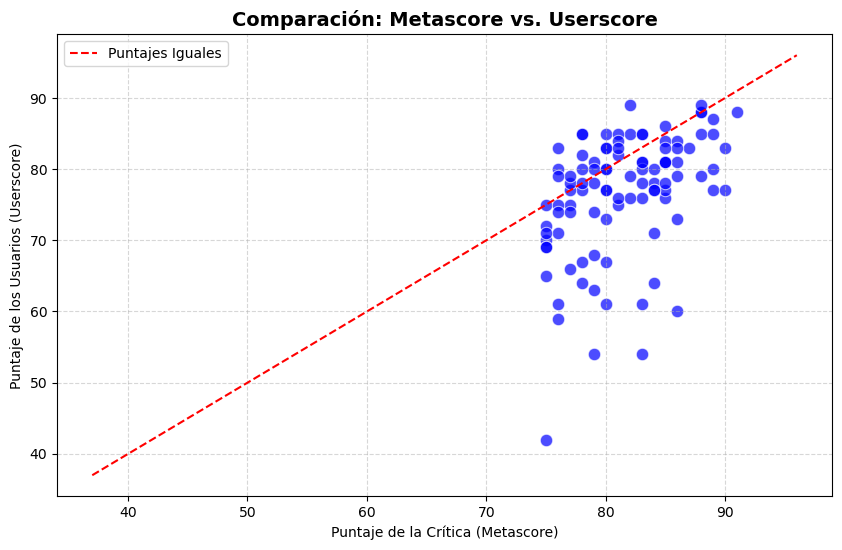

In [12]:
plt.figure(figsize=(10, 6))

sns.scatterplot(data=df, x='metascore', y='userscore', color='blue', alpha=0.7, s=80)

minimo = min(df['metascore'].min(), df['userscore'].min()) - 5
maximo = max(df['metascore'].max(), df['userscore'].max()) + 5
plt.plot([minimo, maximo], [minimo, maximo], color='red', linestyle='--', label='Puntajes Iguales')

plt.title('Comparación: Metascore vs. Userscore', fontsize=14, fontweight='bold')
plt.xlabel('Puntaje de la Crítica (Metascore)')
plt.ylabel('Puntaje de los Usuarios (Userscore)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

Al evaluar el gráfico de dispersión resultante, se evidencia una clara tendencia central. En su gran mayoría, los puntajes otorgados por Metacritic no distan significativamente de las valoraciones de los usuarios. Esta alineación sugiere que no existe una polarización extrema en la muestra analizada; es decir, los títulos bien valorados por la prensa tienden a replicar ese mismo éxito entre la comunidad de jugadores.

### 2.3.2 Analisis de relacion entre metascore y userscore

Con el objetivo de identificar si el género de un videojuego influye significativamente en la percepción de la crítica especializada, se generó un diagrama de cajas cruzando la variable numérica metascore con las categorías individuales extraídas de la columna genres.

In [ ]:
df_expandido = df.assign(genero_individual=df['genres'].dropna().str.split(',')).explode('genero_individual')

df_expandido['genero_individual'] = df_expandido['genero_individual'].str.strip()

df_expandido = df_expandido(subset=['metascore', 'genero_individual'])


plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_expandido, 
    x='genero_individual', 
    y='metascore', 
    hue='genero_individual', 
    palette='pastel', 
    legend=False
)

plt.title('Distribución de Metascore según el Género del Juego', fontsize=14, fontweight='bold')
plt.xlabel('Género', fontsize=12)
plt.ylabel('Puntaje de la Crítica (Metascore)', fontsize=12)

plt.grid(True, axis='y', linestyle='--', alpha=0.6)

plt.show()

SyntaxError: invalid syntax (1466806203.py, line 5)

El hallazgo más destacable es la consistencia de las puntuaciones en todos los géneros. La mayoria de las medianas de Metascore oscilan en un rango muy estrecho ,entre 80 y 82 puntos.<br>
Survival destaca ligeramente como el género con la mediana de aprobación más alta, mostrando una concentración fuerte de juegos exitosos en la crítica.

### 2.3.3 Analisis de relacion entre metascore y userscore

Para conocer la relación entre la cantidad de géneros presentes por plataforma, procederemos a utilizar un mapa de calor. Dado que las variables plataformas y generos contienen múltiples valores combinados por celda, fue necesario aplicar una doble expansión en los datos para obtener una tabla de contingencia precisa. Esta visualización nos permite identificar visualmente las intersecciones con mayor volumen de juegos a través de la intensidad del color.

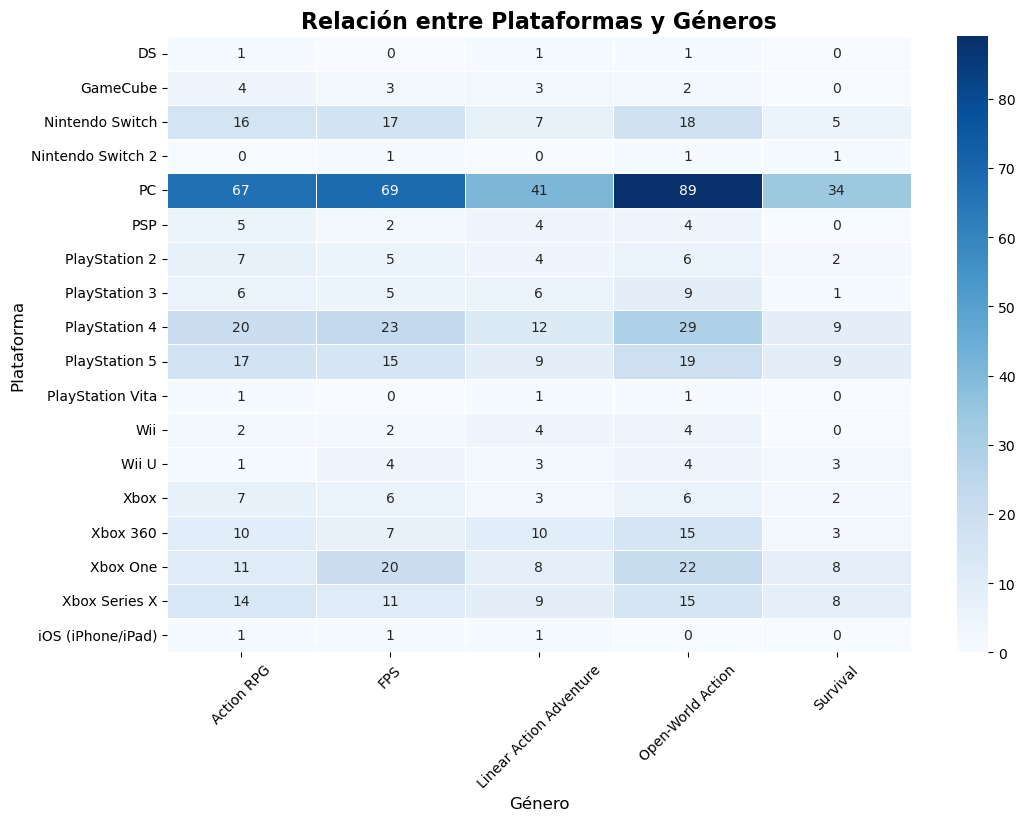

In [15]:
df_gen = df.assign(genero=df['genres'].str.split(',')).explode('genero')
df_gen['genero'] = df_gen['genero'].str.strip()

df_plat_gen = df_gen.assign(plataforma=df_gen['platforms'].str.split(',')).explode('plataforma')
df_plat_gen['plataforma'] = df_plat_gen['plataforma'].str.strip()

tabla_cruzada = pd.crosstab(df_plat_gen['plataforma'], df_plat_gen['genero'])


plt.figure(figsize=(12, 8)) # Hacemos el lienzo un poco más grande

sns.heatmap(tabla_cruzada, annot=True, cmap='Blues', fmt='d', linewidths=.5)

plt.title('Relación entre Plataformas y Géneros', fontsize=16, fontweight='bold')
plt.ylabel('Plataforma', fontsize=12)
plt.xlabel('Género', fontsize=12)

plt.xticks(rotation=45) 

plt.show()

* **Dominancia de PC:** El mapa de calor revela una fuerte asimetría en la distribución. La fila correspondiente a **"PC"** concentra la máxima intensidad en absolutamente todos los géneros, destacando especialmente en *Open-World Action* y *FPS*. Esto indica que la inmensa mayoría de los juegos de la muestra están disponibles en PC, independientemente de en qué otras consolas se hayan lanzado.

* **Distribución en consolas modernas:** Consolas como la *Nintendo Switch*, *PlayStation 4* y *PlayStation 5* muestran una distribución secundaria sólida, acompañando las tendencias generales. Sus catálogos en esta muestra se apoyan fuertemente en los géneros *FPS* y *Open-World Action*, mientras que el género *Survival* tiene una adopción considerablemente menor en estas plataformas.

* **Plataformas minoritarias:** Se observa una gran cantidad de plataformas clásicas o portátiles que registran frecuencias marginales.

## Fase 3 - Preparación de los datos

Se procede a disminuir las columnas del data frame, asi poseemos un data frame util (dfu) con el cual trabajar con comodidad. Las columnas que dejaremos seran las siguientes: id, title, genres, description, platforms, metascore, userscore

procedemos a generar una columna por genero, la cual se le colocara un 1 si el juego posee ese genero en genres y un 0 si no lo posee 

In [12]:
dfu = dfu.copy()

dfu['genres_limpios'] = dfu['genres'].apply(lambda x: '|'.join([g.strip() for g in x.split(',')]))

columnas_generos = dfu['genres_limpios'].str.get_dummies(sep='|')

dfu = pd.concat([dfu, columnas_generos], axis=1)

dfu = dfu.drop(columns=['genres', 'genres_limpios'])

dfu.head()

,id,title,description,platforms,metascore,userscore,Action RPG,FPS,Linear Action Adventure,Open-World Action,Survival
0,1300540639,Outer Wilds: Echoes of the Eye,A strange satellite photo that can’t be explai...,PC,82.0,89,1,0,1,1,0
1,1300473095,Yakuza Kiwami 2,Kazuma Kiryu thought his Tojo Clan days were b...,"PlayStation 4,PC,Xbox One,Nintendo Switch 2",85.0,84,0,1,0,1,1
2,1300536274,Lost Judgment,"SEIZE THE TRUTH - December 2021, Tokyo distric...","PlayStation 5,Xbox Series X,PlayStation 4,PC",82.0,85,0,1,0,1,1
3,1300069209,Darksiders II,"Awakened by the End of Days, Death, the most f...","Xbox 360,PlayStation 3,PC,Wii U",83.0,81,0,1,1,1,0
4,1300491974,Reventure,The one and only non-linear adventure with 100...,"PC,Nintendo Switch",83.0,76,0,1,1,1,0


In [11]:
dfu = df[['id', 'title', 'genres', 'description', 'platforms', 'metascore', 'userscore']]
dfu.head()

,id,title,genres,description,platforms,metascore,userscore
0,1300540639,Outer Wilds: Echoes of the Eye,"Open-World Action, Action RPG, Linear Action A...",A strange satellite photo that can’t be explai...,PC,82.0,89
1,1300473095,Yakuza Kiwami 2,"Open-World Action, FPS, Survival",Kazuma Kiryu thought his Tojo Clan days were b...,"PlayStation 4,PC,Xbox One,Nintendo Switch 2",85.0,84
2,1300536274,Lost Judgment,"Open-World Action, FPS, Survival","SEIZE THE TRUTH - December 2021, Tokyo distric...","PlayStation 5,Xbox Series X,PlayStation 4,PC",82.0,85
3,1300069209,Darksiders II,"Open-World Action, Linear Action Adventure, FPS","Awakened by the End of Days, Death, the most f...","Xbox 360,PlayStation 3,PC,Wii U",83.0,81
4,1300491974,Reventure,"Open-World Action, Linear Action Adventure, FPS",The one and only non-linear adventure with 100...,"PC,Nintendo Switch",83.0,76


## 2.4: Verificación de la calidad de los datos

### Instancia 2.4.X: Análisis de valores nulos
Recapitulando, teníamos 22 valores nulos en el atributo "rating". Los nulos pueden tener varias explicaciones lógicas. Pueden ser porque:
<br>
<br>
* El juego es apto para todo público y no se especificó porque no tiene restricciones.
* El juego no fue clasificado por ESRB.
* El juego si tiene clasificación pero el dataset no la registró porque la clasificación se realizó hace poco y el juego se cargó hace mucho en el dataset.

Esta última explicación hace bastante sentido, así que indagaremos un poco más. Disponemos de la fecha de lanzamiento del juego, así que como también contamos con el atributo "releaseDate", o fecha de lanzamiento en español, podemos comparar los datos que tienen nulo en "rating" y los que no tienen nulo para ver si existe un sesgo en su fecha de lanzamiento y corroborar si la fecha es un justificativo de los valores nulos.

## Fase 4 - Modelado
BLA

## Fase 5 - Evaluación
BLA

## Fase 6 - Despliegue
BLA